# Estadistica de divorcios que se han presentado en México 1994-2024
Se hará una comparativa desde el año 1994 hasta el 2024 para poder hacer la comparación y la disminución o el aumento de estos.

In [126]:
# ANÁLISIS EXPLORATORIO COMPLETO (EDA)
#importar librerías

import pandas as pd
import matplotlib.pyplot as plt
df= pd.read_csv("data\ed_valor_00.csv") 

C:\Users\Lalo\AppData\Local\Temp\ipykernel_13160\1662574004.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("data\ed_valor_00.csv")


In [127]:
#Se muestra la información general del Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77715 entries, 0 to 77714
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   cve_entidad     77715 non-null  int64 
 1   desc_entidad    77715 non-null  object
 2   cve_municipio   77715 non-null  int64 
 3   desc_municipio  77715 non-null  object
 4   id_indicador    77715 non-null  int64 
 5   indicador       77715 non-null  object
 6   año             77715 non-null  int64 
 7   valor           77715 non-null  object
 8   unidad_medida   77715 non-null  object
dtypes: int64(4), object(5)
memory usage: 5.3+ MB


In [128]:
#Haremos un cast en el campo valor para convertirlo a tipo numérico, ya que es necesario para realizar cálculos posteriores
df['valor'] = pd.to_numeric(df['valor'], errors='coerce')

In [129]:
#Se muestra las primeras filas del DataFrame
df.head()

,cve_entidad,desc_entidad,cve_municipio,desc_municipio,id_indicador,indicador,año,valor,unidad_medida
0,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1994,35029.0,Divorcios
1,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1995,37455.0,Divorcios
2,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1996,38545.0,Divorcios
3,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1997,40792.0,Divorcios
4,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1998,45889.0,Divorcios


In [130]:
#Se muestra la cantidad de valores nulos por columna
df.isna().sum()

cve_entidad          0
desc_entidad         0
cve_municipio        0
desc_municipio       0
id_indicador         0
indicador            0
año                  0
valor             4560
unidad_medida        0
dtype: int64

No se encuentran valores nulos en el datashet

In [131]:
#Veremos la cantidad de ceros que tiene cada columna
(df == 0).sum()

cve_entidad         124
desc_entidad          0
cve_municipio      1116
desc_municipio        0
id_indicador          0
indicador             0
año                   0
valor             41012
unidad_medida         0
dtype: int64

Nos encontramos con cve_entidad  124 con valores en 0, cve_municipio  1116 con valores en 0 y valor con 4429 en 0.

In [132]:
#Se mostrara los diferntes valores que se eneuntran en el campo indicador
df['indicador'].unique()

array(['Divorcios', 'Relación divorcios - matrimonios',
       'Divorcios judiciales', 'Divorcios administrativos'], dtype=object)

Los valores arrojados son: Divorcios, Relación divorcios - matrimonios,  Divorcios judiciales y Divorcios administrativos. La pregunta en este punto es ¿Por qué tenemos estos campos?. Para resolver esta duda haremos lo siguinte

In [133]:
#Se filtara los datos del año 1994
df.query("desc_entidad == 'Estados Unidos Mexicanos' and año == 1994")

,cve_entidad,desc_entidad,cve_municipio,desc_municipio,id_indicador,indicador,año,valor,unidad_medida
0,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1994,35029.0,Divorcios
31,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,6200240337,Relación divorcios - matrimonios,1994,5.2,Porcentaje
62,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,6200240402,Divorcios judiciales,1994,28296.0,Divorcios
93,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,6200240506,Divorcios administrativos,1994,6733.0,Divorcios


Nos muestra que los divorcios fueron 35029, mientras que los Divorcios judiciales fueron  28296 y Divorcios administrativos	fueron 6733. Para poder corroborarlo haremos la comprobación

In [134]:
#Mostrar el total de los divorcios en el año 1994
df.query("desc_entidad == 'Estados Unidos Mexicanos' and año == 1994 and indicador == 'Divorcios'")

,cve_entidad,desc_entidad,cve_municipio,desc_municipio,id_indicador,indicador,año,valor,unidad_medida
0,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1994,35029.0,Divorcios


In [135]:
divorcios_94= df[(df['año']==1994) & (df["indicador"].isin(["Divorcios judiciales", "Divorcios administrativos"]))]
total_divorcios_94 = divorcios_94['valor'].sum()
print(f"Total de divorcios en 1994: {total_divorcios_94}")

Total de divorcios en 1994: 35029.0


Como pudimos observar la suma de "Divorcios judiciales" y de "Divorcios administrativos" es el dato que tenemos en divorcios.
La diferencia que radica uno con el otro son la manera de separarse mientras que Divorcios judiciales es  la "disolución del vínculo matrimonial decretada por un juez familiar o civil tras un proceso legal", los Divorcios administrativos son procedimiento rápido, sencillo y económico para disolver el matrimonio ante el Registro Civil (o notario), sin necesidad de juicio.

Con estos datos se trabajara la siguinete grafica para mostrar el total de divorcios del año 1994 al 2023 en toda la republica mexicana 

In [136]:
#Se meuestra el total de los divorcios en el país desde 1994
df.query("desc_municipio == 'Estados Unidos Mexicanos' and indicador == 'Divorcios'")

,cve_entidad,desc_entidad,cve_municipio,desc_municipio,id_indicador,indicador,año,valor,unidad_medida
0,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1994,35029.0,Divorcios
1,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1995,37455.0,Divorcios
2,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1996,38545.0,Divorcios
3,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1997,40792.0,Divorcios
4,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1998,45889.0,Divorcios
5,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,1999,49271.0,Divorcios
6,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,2000,52358.0,Divorcios
7,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,2001,57370.0,Divorcios
8,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,2002,60641.0,Divorcios
9,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,2003,64248.0,Divorcios


Se procedera a sacar la suma y el promedio de los divorcios en mexico 

In [137]:
#Filtramos para que solo considere el indicador "Divorcios"
solo_divorcios = df[(df['indicador'] == "Divorcios") & (df['desc_municipio'] == 'Estados Unidos Mexicanos')]

#Agrupamos por 'año' y calculamos el promedio
promedio_total = solo_divorcios['valor'].mean()
print(f"El promedio de divorcios en Estados Unidos Mexicanos es: {promedio_total}")

El promedio de divorcios en Estados Unidos Mexicanos es: 93446.29032258065


De esta manera podemos observar que el promedio de divrcios en mexico desde 1994 al 2024 es de 93,446 divorcios por año.

Ahora veremos que estado tiene más divorcios 

In [ ]:
#Mayor  numero de divorcios en un año excluyendo el total de divorcios en el país por año
max_divorcios = df[(df['indicador'] == "Divorcios") & (df['desc_entidad'] != "Estados Unidos Mexicanos")]['valor'].max()

df.query("indicador == 'Divorcios' and valor == @max_divorcios")

#print(f"El mayor número de divorcios en un año es: {max_divorcios}")

,cve_entidad,desc_entidad,cve_municipio,desc_municipio,id_indicador,indicador,año,valor,unidad_medida
28,0,Estados Unidos Mexicanos,0,Estados Unidos Mexicanos,1002000039,Divorcios,2022,166766.0,Divorcios


In [151]:
#Menor  numero de divorcios en un año excluyendo el total de divorcios en el país por año
min_divorcios = df[(df['indicador'] == "Divorcios")]['valor'].min()

df.query("indicador == 'Divorcios' and valor == @min_divorcios")

,cve_entidad,desc_entidad,cve_municipio,desc_municipio,id_indicador,indicador,año,valor,unidad_medida
186,1,Aguascalientes,2,Asientos,1002000039,Divorcios,1994,0.0,Divorcios
187,1,Aguascalientes,2,Asientos,1002000039,Divorcios,1995,0.0,Divorcios
188,1,Aguascalientes,2,Asientos,1002000039,Divorcios,1996,0.0,Divorcios
189,1,Aguascalientes,2,Asientos,1002000039,Divorcios,1997,0.0,Divorcios
190,1,Aguascalientes,2,Asientos,1002000039,Divorcios,1998,0.0,Divorcios
...,...,...,...,...,...,...,...,...,...
77710,32,Zacatecas,996,No especificado,1002000039,Divorcios,2020,0.0,Divorcios
77711,32,Zacatecas,996,No especificado,1002000039,Divorcios,2021,0.0,Divorcios
77712,32,Zacatecas,996,No especificado,1002000039,Divorcios,2022,0.0,Divorcios
77713,32,Zacatecas,996,No especificado,1002000039,Divorcios,2023,0.0,Divorcios


In [ ]:
#Se mostrará el promedio de divoricios por año de cada estado
df_filtrado = df[(df['indicador'] == 'Divorcios') & 
                  (df['desc_entidad'] != 'Estados Unidos Mexicanos')]

# Agrupamos solo por Estado para promediar todos sus años (1994-2024)
promedio_historico_estado = df_filtrado.groupby('desc_entidad')['valor'].mean().sort_values(ascending=False)

# 3. Mostramos el resultado
print("Promedio anual de divorcios por estado (1994-2024):")
print(promedio_historico_estado)

Promedio anual de divorcios por estado (1994-2024):
desc_entidad
Ciudad de México                   1038.074349
Baja California                     937.380488
Sinaloa                             414.585000
Nuevo León                          290.062847
Aguascalientes                      280.109661
Quintana Roo                        272.575581
Baja California Sur                 215.868020
Guanajuato                          206.538147
Campeche                            204.895141
Coahuila de Zaragoza                202.888525
Querétaro                           176.880000
México                              169.892264
Tabasco                             162.372583
Chihuahua                           161.217555
Tamaulipas                          145.392000
Colima                              138.642045
Nayarit                              92.516616
Sonora                               84.000880
Durango                              69.851319
Morelos                              64.80

Estos datos revelan que el lugar donde más divorcios hubo fue en el estado de méxico con 166,766 divorcios en el 2022, mientras que la CDMX tiene el promedio de divorcios más alto desde 1994 al 2024.

Vamos a centrarnos en la CDMX y veremos que año hubo más divorcios para posteriormente ver los número de las alcaldías

In [178]:
# Agrupamos por entidad Y por año para ver la serie histórica
cdmx_anual = df_filtrado_cdmx.groupby(['desc_entidad', 'año'])['valor'].sum().reset_index()

# Ordenamos de mayor a menor y tomamos los primeros 10
top_10_anios = cdmx_anual.sort_values(by='valor', ascending=False).head(10)

print(top_10_anios)



        desc_entidad   año    valor
22  Ciudad de México  2016  12780.0
24  Ciudad de México  2018  12720.0
23  Ciudad de México  2017  12631.0
25  Ciudad de México  2019  12221.0
21  Ciudad de México  2015  12214.0
28  Ciudad de México  2022  11682.0
17  Ciudad de México  2011  11385.0
18  Ciudad de México  2012  11105.0
16  Ciudad de México  2010  11053.0
19  Ciudad de México  2013  11030.0


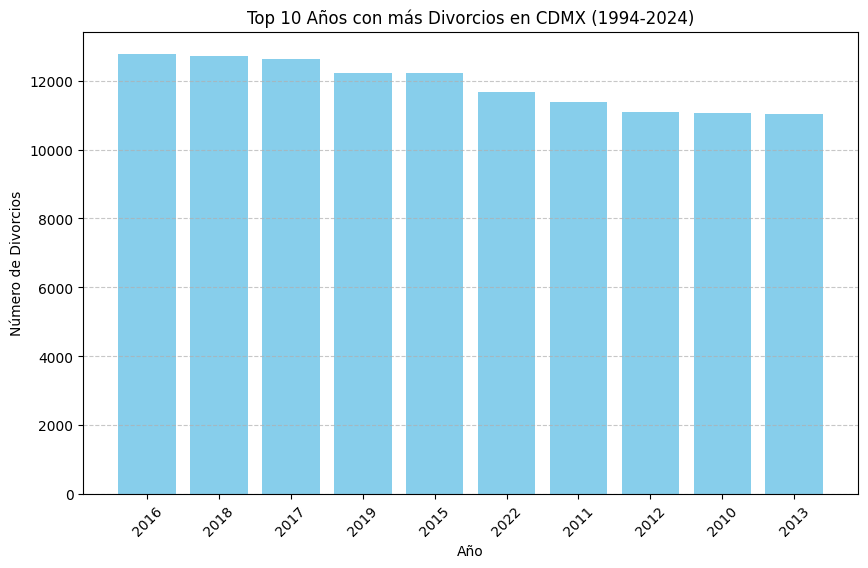

In [179]:
# Graficamos
plt.figure(figsize=(10, 6))
plt.bar(top_10_anios['año'].astype(str), top_10_anios['valor'], color='skyblue')
plt.title('Top 10 Años con más Divorcios en CDMX (1994-2024)')
plt.xlabel('Año')
plt.ylabel('Número de Divorcios')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Por último veremos que alcaldías hubo más divorcios en el 2016.

In [182]:
# Agrupamos por entidad Y por año para ver la serie histórica
alcaldias_df = df[(df['desc_entidad'] == 'Ciudad de México') & (df['desc_municipio'] != 'Estatal')]

# Agrupamos por MUNICIPIO (Alcaldía) y AÑO
# Queremos ver: ¿Qué alcaldía y en qué año tuvo más divorcios?
resumen_alcaldias = alcaldias_df.groupby(['desc_municipio', 'año'])['valor'].sum().reset_index()
#Ordenamos para ver el Top 10 histórico de las alcaldías
top_10_alcaldias = resumen_alcaldias.sort_values(by='valor', ascending=False).head(10)

print(top_10_alcaldias)



    desc_municipio   año    valor
146     Cuauhtémoc  2016  10090.0
147     Cuauhtémoc  2017   9962.0
148     Cuauhtémoc  2018   9904.0
145     Cuauhtémoc  2015   9636.0
149     Cuauhtémoc  2019   9498.0
152     Cuauhtémoc  2022   8852.0
141     Cuauhtémoc  2011   8806.0
140     Cuauhtémoc  2010   8692.0
142     Cuauhtémoc  2012   8556.0
143     Cuauhtémoc  2013   8525.0


La grafica nos muentra que el año con mayor número de divorcios fue el año 2017 mientras que el año con menor número de divorcios fue el 2020, esto fue por el cierre de los juzgados en la pandemia.

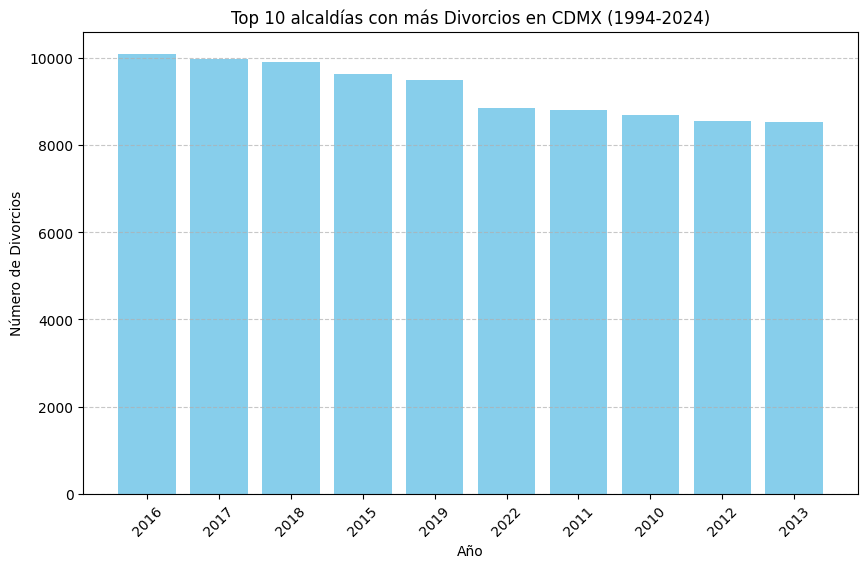

In [183]:
# Graficamos
plt.figure(figsize=(10, 6))
plt.bar(top_10_alcaldias['año'].astype(str), top_10_alcaldias['valor'], color='skyblue')
plt.title('Top 10 alcaldías con más Divorcios en CDMX (1994-2024)')
plt.xlabel('Año')
plt.ylabel('Número de Divorcios')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()